In [1]:
import Pkg
Pkg.activate(".")
Pkg.status()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising`


Status `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [91a5bcdd] Plots v1.41.6
  [925ea013] ProxTV v1.2.3
  [9a3f8284] Random v1.11.0


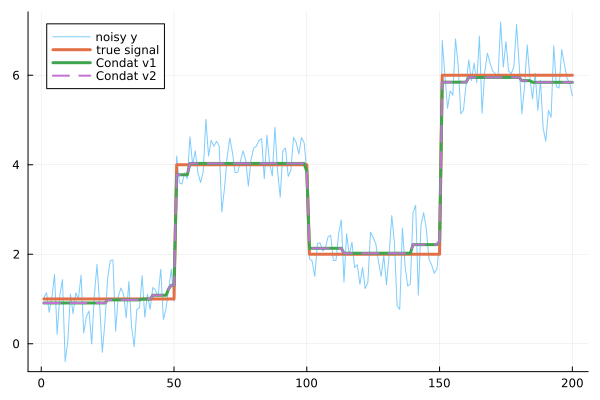

In [2]:
using Random
using Plots

include("src/1D_denoising.jl")

Random.seed!(1)
N = 200
xtrue = vcat(
    fill(1.0, 50),
    fill(4.0, 50),
    fill(2.0, 50),
    fill(6.0, 50)
)
y = xtrue .+ 0.5 .* randn(N)
λ = 3.0
x_v1 = tv1d_condat_v1(y, λ)
x_v2 = tv1d_condat_v2(y, λ)

plot(y, label="noisy y", alpha=0.5)
plot!(xtrue, label="true signal", linewidth=3)
plot!(x_v1, label="Condat v1", linewidth=3)
plot!(x_v2, label="Condat v2", linewidth=2, linestyle=:dash)

In [ ]:
using BenchmarkTools
using LinearAlgebra
using ProxTV
using Random

include("src/1D_denoising.jl")

function proxtv_1d(y, λ)
    h = NormTVp(λ, 1.0, length(y))
    x = similar(y, Float64)
    prox!(x, h, y, 1.0)
    return x
end

Random.seed!(1)
Ns = [1, 2, 3, 10, 200, 1_000]
λs = [0.0, 0.1, 3.0]

println("Correctness check against v1 and ProxTV.jl")
for N in Ns, λ in λs
    y = randn(N)
    x_v1 = tv1d_condat_v1(y, λ)
    x_v2 = tv1d_condat_v2(y, λ)
    x_proxtv = proxtv_1d(y, λ)
    err_v1_v2 = norm(x_v1 - x_v2, Inf)
    err_v2_proxtv = norm(x_v2 - x_proxtv, Inf)
    println("N=$N, λ=$λ:  ||v1-v2||∞ = $err_v1_v2,  ||v2-ProxTV||∞ = $err_v2_proxtv")
end

println("\nBenchmark median time and memory")
for N in [200, 2_000, 20_000]
    Random.seed!(N)
    y = randn(N)
    λ = 3.0
    h = NormTVp(λ, 1.0, N)
    b_v1 = @benchmark tv1d_condat_v1($y, $λ)
    b_v2 = @benchmark tv1d_condat_v2($y, $λ)
    b_proxtv = @benchmark begin
        x = similar($y)
        prox!(x, $h, $y, 1.0)
    end
    println("\nN=$N")
    println("Condat v1: ", median(b_v1).time / 1e6, " ms, ", median(b_v1).memory, " bytes")
    println("Condat v2: ", median(b_v2).time / 1e6, " ms, ", median(b_v2).memory, " bytes")
    println("ProxTV.jl: ", median(b_proxtv).time / 1e6, " ms, ", median(b_proxtv).memory, " bytes")
end

Correctness check against v1 and ProxTV.jl
N=1, λ=0.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=1, λ=0.1:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=1, λ=3.0:  ||v1-v2||∞ = 2.220446049250313e-16,  ||v2-ProxTV||∞ = 2.220446049250313e-16
N=2, λ=0.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=2, λ=0.1:  ||v1-v2||∞ = 2.220446049250313e-16,  ||v2-ProxTV||∞ = 0.0
N=2, λ=3.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=3, λ=0.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=3, λ=0.1:  ||v1-v2||∞ = 2.220446049250313e-16,  ||v2-ProxTV||∞ = 0.0
N=3, λ=3.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=10, λ=0.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=10, λ=0.1:  ||v1-v2||∞ = 2.7755575615628914e-17,  ||v2-ProxTV||∞ = 2.7755575615628914e-17
N=10, λ=3.0:  ||v1-v2||∞ = 2.220446049250313e-16,  ||v2-ProxTV||∞ = 2.220446049250313e-16
N=200, λ=0.0:  ||v1-v2||∞ = 0.0,  ||v2-ProxTV||∞ = 0.0
N=200, λ=0.1:  ||v1-v2||∞ = 1.6653345369377348e-16,  ||v2-ProxTV||∞ = 1.6653345369377348e-16
N=200, λ=3.0:  ||v1-v2||

In [1]:
using Random
using LinearAlgebra

include("src/2D_denoising.jl")
Random.seed!(1)

x = randn(64, 64)

av, dv, ah, dh = W_kamilov_2d(x)
x_rec = WT_kamilov_2d(av, dv, ah, dh)

println(norm(x_rec - x) / norm(x))

1.9365990943041136e-16
